Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
First 5 rows:
    Species       Breed  Gender  Cattle_dob  Total_lactation Current_Lactation  \
0      Cow    HF Cross  Female        2019                1               Dry   
1  Buffalo      Murrah  Female        2018                2           Milking   
2  Buffalo      Murrah  Female        2018                2               Dry   
3      Cow    HF Cross  Female        2019                1           Milking   
4  Buffalo  Desi Cross  Female        2018                1               Dry   

   Milk Litre  Price  
0          24  75000  
1           8  85000  
2           8  85000  
3           7  27000  
4          10  45000  

Columns: Index(['Species', 'Breed', 'Gender', 'Cattle_dob', 'Total_lactation',
       'Current_Lactation', 'Milk Litre', 'Price'],
      dtype='object')

Missing values:
 Species              0
Breed                0
Gender       

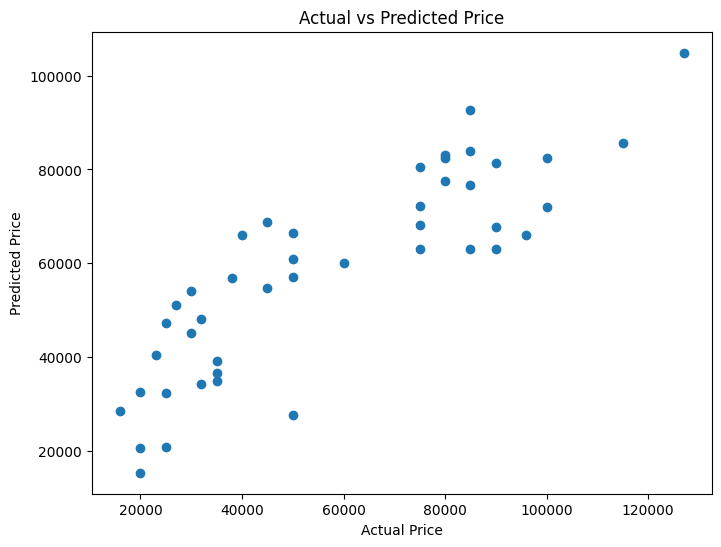

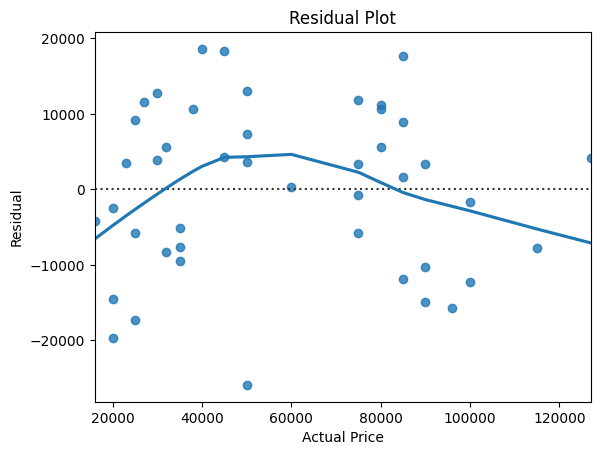

Predicted price for new sample: 65914.01340239402


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error
import joblib
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load the data
df = pd.read_excel("/content/drive/MyDrive/Price Prediction/animal.xlsx")

# Optional: Inspect data
print("First 5 rows:\n", df.head())
print("\nColumns:", df.columns)
print("\nMissing values:\n", df.isnull().sum())

# Prepare features and label
X = df[['Species', 'Breed', 'Gender', 'Cattle_dob', 'Total_lactation', 'Current_Lactation', 'Milk Litre']]
y = df['Price']

# Encode categorical variables
categorical_cols = ['Species', 'Breed', 'Gender', 'Current_Lactation']
ohe = OneHotEncoder(handle_unknown='ignore')
column_trans = make_column_transformer(
    (ohe, categorical_cols),
    remainder='passthrough'
)

# Create pipeline with preprocessing and model
model = LinearRegression()
pipe = make_pipeline(column_trans, model)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
pipe.fit(X_train, y_train)

# Predict on test set
y_pred = pipe.predict(X_test)

# Evaluate model performance
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Plot Actual vs Predicted prices
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()

# Plot residuals
sns.residplot(x=y_test, y=y_pred, lowess=True)
plt.xlabel('Actual Price')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()

# Save the trained pipeline/model
joblib.dump(pipe, '/content/drive/MyDrive/Price Prediction/cattle_price_model.pkl')

# Load saved model example (optional)
# pipe = joblib.load('/content/drive/MyDrive/Price Prediction/cattle_price_model.pkl')

# Predict price for a new sample
new_sample = pd.DataFrame({
    'Species': ['Buffalo'],
    'Breed': ['Murrah'],
    'Gender': ['Female'],
    'Cattle_dob': ['2020'],
    'Total_lactation': [2],
    'Current_Lactation': ['Milking'],
    'Milk Litre': [10]
})
predicted_price = pipe.predict(new_sample)
print("Predicted price for new sample:", predicted_price[0])